# 10: LightGBM

## 1. Imports

In [1]:
from pathlib import Path
import sys

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV,
    train_test_split,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from sklearn.calibration import CalibrationDisplay

from lightgbm import (
    LGBMClassifier,
    early_stopping,
)

from src.config import PROJECT_ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    TRAIN_CLEAN_PATH,
    TRAIN_FEATURED_PATH,
    SPLIT_MANIFEST_PATH,
    MODELS_DIR,
    RESULTS_DIR,
    TARGET,
    ID_COLUMN,
    RANDOM_STATE,
)

pd.set_option("display.max_columns", 100)


## 2. Load Dataset

In [2]:
clean = pd.read_csv(TRAIN_CLEAN_PATH)
featured = pd.read_csv(TRAIN_FEATURED_PATH)
manifest = pd.read_csv(SPLIT_MANIFEST_PATH)

train_ids = set(
    manifest.loc[
        manifest["Split"] == "train",
        ID_COLUMN,
    ]
)

holdout_ids = set(
    manifest.loc[
        manifest["Split"] == "test",
        ID_COLUMN,
    ]
)

def split_by_manifest(df):
    development = (
        df[df[ID_COLUMN].isin(train_ids)]
        .sort_values(ID_COLUMN)
        .reset_index(drop=True)
    )

    holdout = (
        df[df[ID_COLUMN].isin(holdout_ids)]
        .sort_values(ID_COLUMN)
        .reset_index(drop=True)
    )

    return development, holdout

clean_dev, clean_holdout = split_by_manifest(clean)
featured_dev, featured_holdout = split_by_manifest(featured)

print("Development rows:", len(clean_dev))
print("Holdout rows:", len(clean_holdout))
print("Development attrition rate:", f"{clean_dev[TARGET].mean():.1%}")
print("Holdout attrition rate:", f"{clean_holdout[TARGET].mean():.1%}")

Development rows: 846
Holdout rows: 212
Development attrition rate: 16.9%
Holdout attrition rate: 17.0%


## 3. Build Pipeline

In [3]:
def build_lightgbm_pipeline(
    X,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    scale_pos_weight=1.0,
):
    categorical_columns = [
        column for column in X.columns
        if not pd.api.types.is_numeric_dtype(X[column])
    ]

    numeric_columns = [
        column for column in X.columns
        if column not in categorical_columns
    ]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ])

    classifier = LGBMClassifier(
        objective="binary",
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        min_child_samples=min_child_samples,
        subsample=subsample,
        subsample_freq=1,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        scale_pos_weight=scale_pos_weight,
        importance_type="gain",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ])

## 4. Compare Features (Original vs. Engineered)

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

comparison_rows = []

for feature_set_name, development_df in [
    ("Original cleaned features", clean_dev),
    ("Engineered candidate features", featured_dev),
]:
    X = development_df.drop(columns=[TARGET, ID_COLUMN])
    y = development_df[TARGET]

    scores = cross_validate(
        build_lightgbm_pipeline(X),
        X,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
        },
        n_jobs=-1,
    )

    comparison_rows.append({
        "feature_set": feature_set_name,
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": scores["test_roc_auc"].std(),
        "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
        "cv_pr_auc_std": scores["test_pr_auc"].std(),
    })

feature_comparison = pd.DataFrame(comparison_rows)

feature_comparison.round(4)

,feature_set,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,Original cleaned features,0.7935,0.0435,0.5436,0.0519
1,Engineered candidate features,0.8047,0.0398,0.5416,0.0519


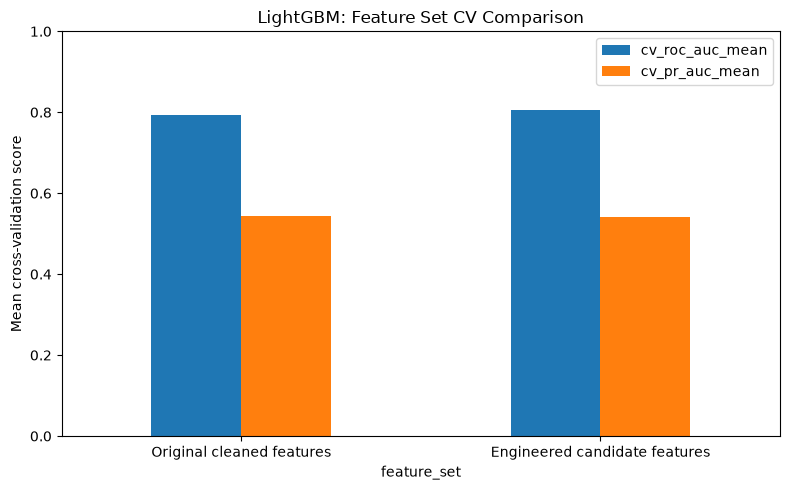

In [5]:
feature_comparison.set_index("feature_set")[
    ["cv_roc_auc_mean", "cv_pr_auc_mean"]
].plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("LightGBM: Feature Set CV Comparison")
plt.ylabel("Mean cross-validation score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
selected_name = (
    feature_comparison
    .sort_values("cv_pr_auc_mean", ascending=False)
    .iloc[0]["feature_set"]
)

print("Selected feature set:", selected_name)

if selected_name == "Engineered candidate features":
    development = featured_dev
    holdout = featured_holdout
else:
    development = clean_dev
    holdout = clean_holdout

X_dev = development.drop(columns=[TARGET, ID_COLUMN])
y_dev = development[TARGET]

X_holdout = holdout.drop(columns=[TARGET, ID_COLUMN])
y_holdout = holdout[TARGET]

negative_positive_ratio = (
    (y_dev == 0).sum()
    / (y_dev == 1).sum()
)

print(
    "Negative / positive ratio:",
    round(negative_positive_ratio, 2),
)

Selected feature set: Original cleaned features
Negative / positive ratio: 4.92


## 5. Tune LightGBM

In [7]:
pipeline = build_lightgbm_pipeline(X_dev)

param_distributions = {
    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.08,
        0.1,
        0.15,
    ],
    "classifier__n_estimators": [
        100,
        200,
        400,
        700,
        1000,
    ],
    "classifier__num_leaves": [
        7,
        15,
        31,
        63,
    ],
    "classifier__max_depth": [
        -1,
        3,
        4,
        5,
        6,
    ],
    "classifier__min_child_samples": [
        10,
        20,
        30,
        50,
        75,
    ],
    "classifier__subsample": [
        0.6,
        0.8,
        1.0,
    ],
    "classifier__colsample_bytree": [
        0.6,
        0.8,
        1.0,
    ],
    "classifier__reg_alpha": [
        0.0,
        0.01,
        0.1,
        0.5,
        1.0,
    ],
    "classifier__reg_lambda": [
        0.0,
        0.5,
        1.0,
        2.0,
        5.0,
        10.0,
    ],
    "classifier__scale_pos_weight": [
        1.0,
        negative_positive_ratio / 2,
        negative_positive_ratio,
    ],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=60,
    scoring={
        "pr_auc": "average_precision",
        "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy",
        "recall": "recall",
        "f1": "f1",
    },
    refit="pr_auc",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    return_train_score=True,
    verbose=1,
)

search.fit(X_dev, y_dev)

print("Best parameters:")
print(search.best_params_)
print()
print("Best CV PR-AUC:", round(search.best_score_, 4))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters:
{'classifier__subsample': 0.6, 'classifier__scale_pos_weight': np.float64(2.458041958041958), 'classifier__reg_lambda': 0.5, 'classifier__reg_alpha': 0.1, 'classifier__num_leaves': 7, 'classifier__n_estimators': 1000, 'classifier__min_child_samples': 75, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}

Best CV PR-AUC: 0.6211


In [8]:
tuning_results = pd.DataFrame(
    search.cv_results_
)

tuning_view = tuning_results[[
    "param_classifier__learning_rate",
    "param_classifier__n_estimators",
    "param_classifier__num_leaves",
    "param_classifier__max_depth",
    "param_classifier__min_child_samples",
    "param_classifier__subsample",
    "param_classifier__colsample_bytree",
    "param_classifier__reg_alpha",
    "param_classifier__reg_lambda",
    "param_classifier__scale_pos_weight",
    "mean_train_pr_auc",
    "mean_test_pr_auc",
    "std_test_pr_auc",
    "mean_test_roc_auc",
    "mean_test_balanced_accuracy",
    "mean_test_recall",
    "mean_test_f1",
    "rank_test_pr_auc",
]].copy()

tuning_view["overfit_gap"] = (
    tuning_view["mean_train_pr_auc"]
    - tuning_view["mean_test_pr_auc"]
)

tuning_view = tuning_view.sort_values(
    "rank_test_pr_auc"
)

tuning_view.head(10).round(4)

,param_classifier__learning_rate,param_classifier__n_estimators,param_classifier__num_leaves,param_classifier__max_depth,param_classifier__min_child_samples,param_classifier__subsample,param_classifier__colsample_bytree,param_classifier__reg_alpha,param_classifier__reg_lambda,param_classifier__scale_pos_weight,mean_train_pr_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_recall,mean_test_f1,rank_test_pr_auc,overfit_gap
28,0.01,1000,7,5,75,0.6,0.8,0.10,0.5,2.458,0.8499,0.6211,0.0362,0.8249,0.7259,0.5244,0.5591,1,0.2288
26,0.03,200,7,3,50,0.6,0.8,0.10,10.0,2.458,0.7800,0.5931,0.0365,0.8106,0.7005,0.4680,0.5209,2,0.1869
46,0.01,700,7,4,30,0.6,0.6,0.10,0.0,1.000,0.9348,0.5918,0.0354,0.8120,0.6245,0.2788,0.3898,3,0.3431
4,0.01,400,7,6,10,0.6,0.6,0.10,0.0,1.000,0.9239,0.5862,0.0481,0.8016,0.6079,0.2300,0.3507,4,0.3376
41,0.15,100,7,4,75,0.6,1.0,0.01,5.0,1.000,0.8415,0.5849,0.0288,0.8157,0.6387,0.3002,0.4221,5,0.2566
56,0.15,200,7,6,75,1.0,0.6,0.50,10.0,1.000,0.9658,0.5750,0.0438,0.8055,0.6554,0.3421,0.4570,6,0.3908
54,0.03,400,7,-1,50,0.8,1.0,0.01,0.0,1.000,0.9921,0.5734,0.0314,0.8104,0.6652,0.3631,0.4760,7,0.4188
18,0.05,400,63,4,10,0.6,0.6,0.01,10.0,1.000,0.9859,0.5719,0.0698,0.8112,0.6374,0.3005,0.4212,8,0.4140
37,0.01,700,15,5,10,0.6,0.6,0.10,5.0,1.000,0.9563,0.5705,0.0469,0.8054,0.6134,0.2438,0.3633,9,0.3858
57,0.15,200,31,-1,75,0.6,0.8,0.10,1.0,2.458,0.9523,0.5675,0.0542,0.8227,0.7147,0.5106,0.5355,10,0.3848


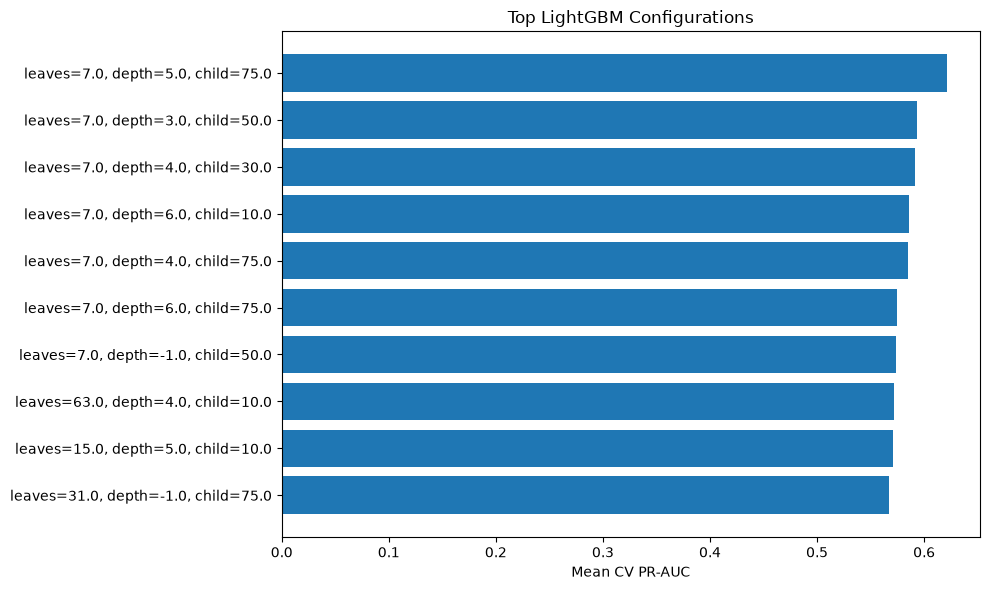

In [9]:
top_tuning = tuning_view.head(10).copy()

def configuration_label(row):
    return (
        f"leaves={row['param_classifier__num_leaves']}, "
        f"depth={row['param_classifier__max_depth']}, "
        f"child={row['param_classifier__min_child_samples']}"
    )

top_tuning["configuration"] = top_tuning.apply(
    configuration_label,
    axis=1,
)

top_tuning = top_tuning.sort_values(
    "mean_test_pr_auc",
    ascending=True,
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_tuning["configuration"].astype(str),
    pd.to_numeric(top_tuning["mean_test_pr_auc"]),
)

plt.xlabel("Mean CV PR-AUC")
plt.title("Top LightGBM Configurations")
plt.tight_layout()
plt.show()

## 6. Check for Overfitting

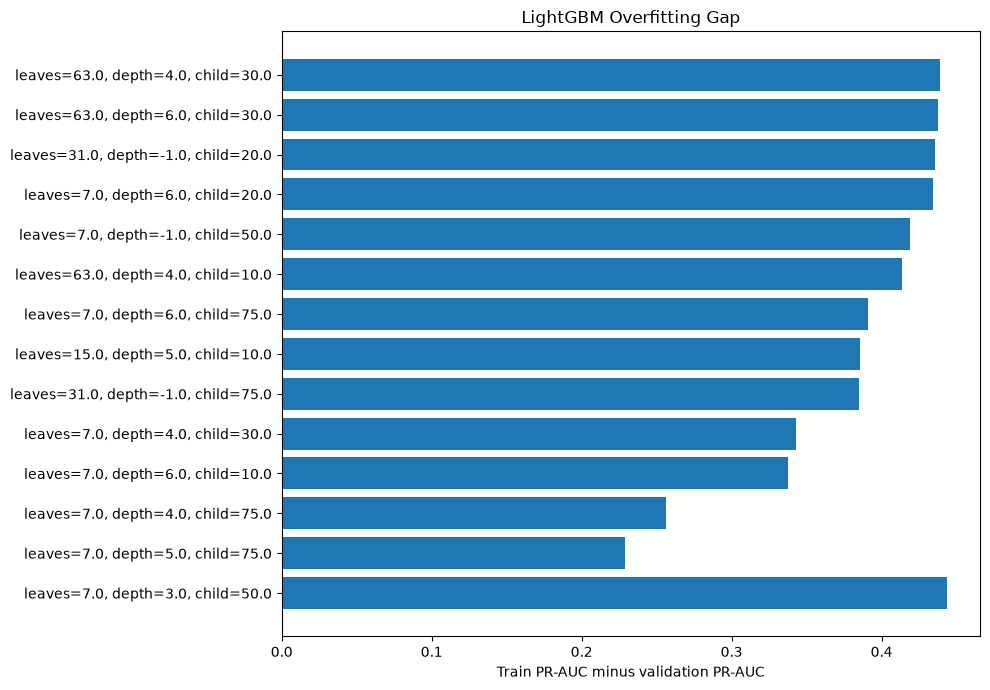

In [10]:
overfit_view = tuning_view.head(15).copy()

overfit_view["configuration"] = overfit_view.apply(
    configuration_label,
    axis=1,
)

overfit_view = overfit_view.sort_values(
    "overfit_gap",
    ascending=True,
)

plt.figure(figsize=(10, 7))

plt.barh(
    overfit_view["configuration"].astype(str),
    overfit_view["overfit_gap"],
)

plt.xlabel("Train PR-AUC minus validation PR-AUC")
plt.title("LightGBM Overfitting Gap")
plt.tight_layout()
plt.show()

In [11]:
best_search_row = tuning_view.iloc[0]

print(
    "Best configuration training PR-AUC:",
    round(best_search_row["mean_train_pr_auc"], 4),
)

print(
    "Best configuration validation PR-AUC:",
    round(best_search_row["mean_test_pr_auc"], 4),
)

print(
    "Overfit gap:",
    round(best_search_row["overfit_gap"], 4),
)

Best configuration training PR-AUC: 0.8499
Best configuration validation PR-AUC: 0.6211
Overfit gap: 0.2288


## 7. Parameter Plot

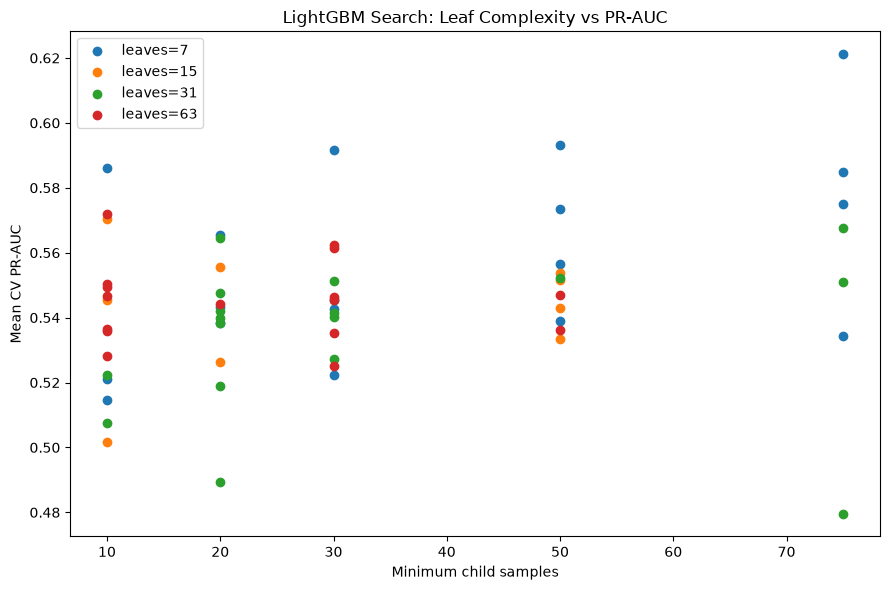

In [12]:
parameter_plot = tuning_view.copy()

parameter_plot["num_leaves"] = pd.to_numeric(
    parameter_plot["param_classifier__num_leaves"]
)

parameter_plot["min_child_samples"] = pd.to_numeric(
    parameter_plot["param_classifier__min_child_samples"]
)

parameter_plot["mean_test_pr_auc"] = pd.to_numeric(
    parameter_plot["mean_test_pr_auc"]
)

plt.figure(figsize=(9, 6))

for leaves in sorted(
    parameter_plot["num_leaves"].unique()
):
    rows = parameter_plot[
        parameter_plot["num_leaves"] == leaves
    ]

    plt.scatter(
        rows["min_child_samples"],
        rows["mean_test_pr_auc"],
        label=f"leaves={int(leaves)}",
    )

plt.xlabel("Minimum child samples")
plt.ylabel("Mean CV PR-AUC")
plt.title("LightGBM Search: Leaf Complexity vs PR-AUC")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Early Stopping

In [13]:
X_es_train, X_es_valid, y_es_train, y_es_valid = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    stratify=y_dev,
    random_state=RANDOM_STATE,
)

best_search_params = {
    name.replace("classifier__", ""): value
    for name, value in search.best_params_.items()
}

search_tree_count = int(
    best_search_params.pop("n_estimators")
)

early_stop_preprocessor = clone(
    search.best_estimator_.named_steps[
        "preprocessor"
    ]
)

X_es_train_processed = (
    early_stop_preprocessor.fit_transform(
        X_es_train
    )
)

X_es_valid_processed = (
    early_stop_preprocessor.transform(
        X_es_valid
    )
)

early_stop_model = LGBMClassifier(
    objective="binary",
    n_estimators=max(
        3000,
        search_tree_count,
    ),
    subsample_freq=1,
    importance_type="gain",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
    **best_search_params,
)

early_stop_model.fit(
    X_es_train_processed,
    y_es_train,
    eval_set=[
        (
            X_es_valid_processed,
            y_es_valid,
        ),
    ],
    eval_metric="average_precision",
    callbacks=[
        early_stopping(
            stopping_rounds=75,
            first_metric_only=True,
            verbose=False,
        ),
    ],
)

optimal_n_estimators = (
    early_stop_model.best_iteration_
)

print(
    "Tree count from randomized search:",
    search_tree_count,
)

print(
    "Early-stopped tree count:",
    optimal_n_estimators,
)

print(
    "Best validation PR-AUC:",
    round(
        early_stop_model.best_score_[
            "valid_0"
        ]["average_precision"],
        4,
    ),
)

Tree count from randomized search: 1000
Early-stopped tree count: 241
Best validation PR-AUC: 0.6961


C:\Users\jeffh\PycharmProjects\employee-attrition\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


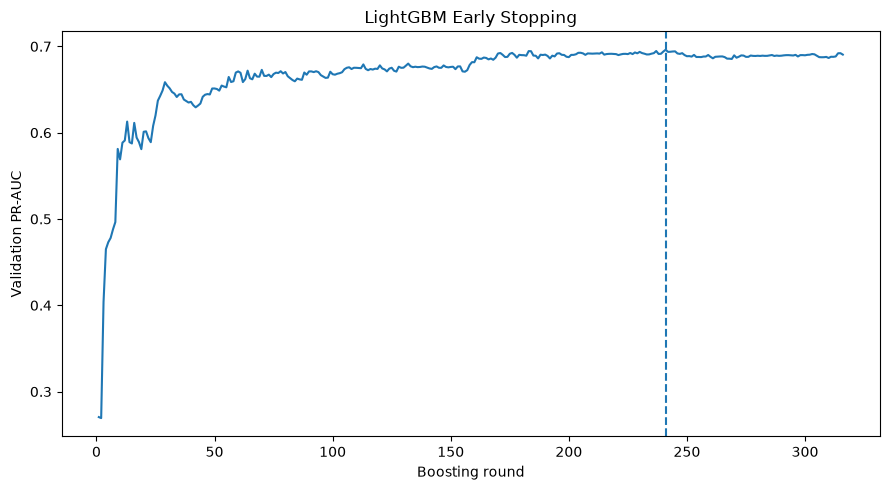

In [14]:
evaluation_history = (
    early_stop_model.evals_result_
)

validation_pr_auc = evaluation_history[
    "valid_0"
]["average_precision"]

plt.figure(figsize=(9, 5))

plt.plot(
    range(
        1,
        len(validation_pr_auc) + 1,
    ),
    validation_pr_auc,
)

plt.axvline(
    optimal_n_estimators,
    linestyle="--",
)

plt.xlabel("Boosting round")
plt.ylabel("Validation PR-AUC")
plt.title("LightGBM Early Stopping")
plt.tight_layout()
plt.show()

## 9. Retrain on all development data

In [15]:
final_model = build_lightgbm_pipeline(
    X_dev,
    n_estimators=optimal_n_estimators,
    learning_rate=best_search_params[
        "learning_rate"
    ],
    num_leaves=best_search_params[
        "num_leaves"
    ],
    max_depth=best_search_params[
        "max_depth"
    ],
    min_child_samples=best_search_params[
        "min_child_samples"
    ],
    subsample=best_search_params[
        "subsample"
    ],
    colsample_bytree=best_search_params[
        "colsample_bytree"
    ],
    reg_alpha=best_search_params[
        "reg_alpha"
    ],
    reg_lambda=best_search_params[
        "reg_lambda"
    ],
    scale_pos_weight=best_search_params[
        "scale_pos_weight"
    ],
)

final_model.fit(
    X_dev,
    y_dev,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

## 10. Generate development OOF probabilities

In [16]:
oof_probability = cross_val_predict(
    final_model,
    X_dev,
    y_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

print(
    "OOF ROC-AUC:",
    round(
        roc_auc_score(
            y_dev,
            oof_probability,
        ),
        4,
    ),
)

print(
    "OOF PR-AUC:",
    round(
        average_precision_score(
            y_dev,
            oof_probability,
        ),
        4,
    ),
)


OOF ROC-AUC: 0.7873
OOF PR-AUC: 0.5362


## 11. Evaluate

In [17]:
holdout_probability = final_model.predict_proba(
    X_holdout
)[:, 1]

holdout_prediction = final_model.predict(
    X_holdout
)

metrics = pd.DataFrame([{
    "accuracy": accuracy_score(
        y_holdout,
        holdout_prediction,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_holdout,
        holdout_prediction,
    ),
    "precision": precision_score(
        y_holdout,
        holdout_prediction,
        zero_division=0,
    ),
    "recall": recall_score(
        y_holdout,
        holdout_prediction,
        zero_division=0,
    ),
    "f1": f1_score(
        y_holdout,
        holdout_prediction,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_holdout,
        holdout_probability,
    ),
    "pr_auc": average_precision_score(
        y_holdout,
        holdout_probability,
    ),
    "brier_score": brier_score_loss(
        y_holdout,
        holdout_probability,
    ),
}])

metrics.round(4)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,0.8255,0.6518,0.4828,0.3889,0.4308,0.773,0.4558,0.1328


## 12. Confusion Matrix

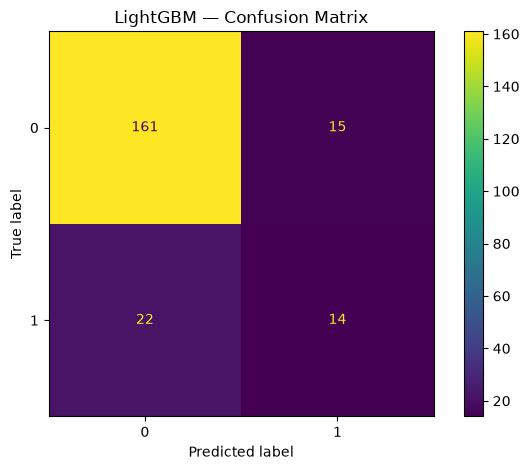

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_holdout,
    holdout_prediction,
)

plt.title("LightGBM — Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. ROC Curve

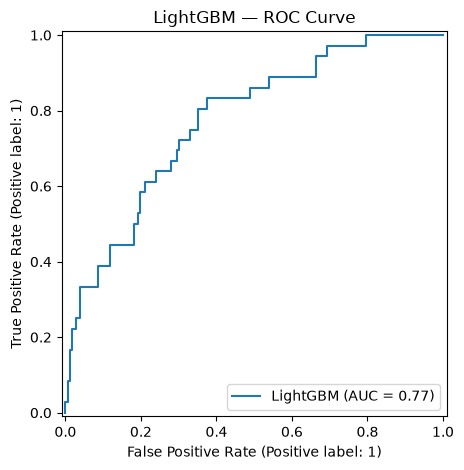

In [19]:
RocCurveDisplay.from_predictions(
    y_holdout,
    holdout_probability,
    name="LightGBM",
)

plt.title("LightGBM — ROC Curve")
plt.tight_layout()
plt.show()

## 14. Precision–Recall curve

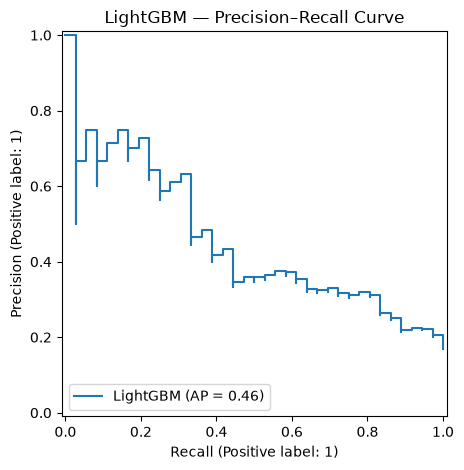

In [20]:
PrecisionRecallDisplay.from_predictions(
    y_holdout,
    holdout_probability,
    name="LightGBM",
)

plt.title("LightGBM — Precision–Recall Curve")
plt.tight_layout()
plt.show()

## 15. Predicted probability distributions

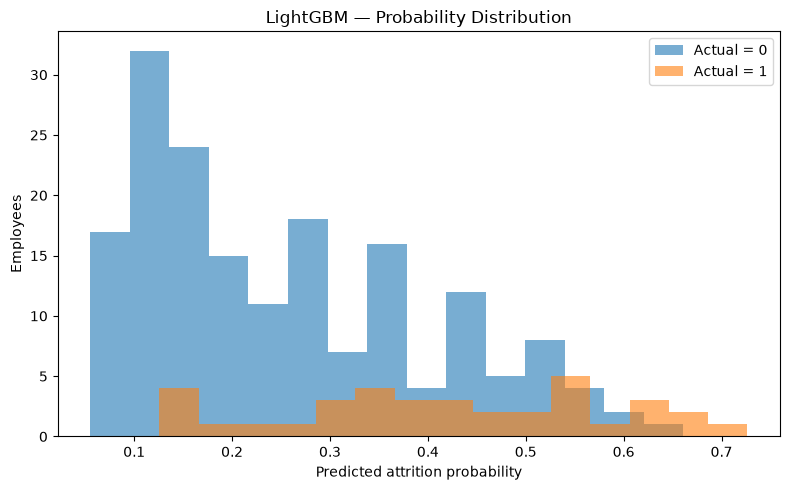

In [21]:
probability_frame = pd.DataFrame({
    "Actual": y_holdout.values,
    "Probability": holdout_probability,
})

plt.figure(figsize=(8, 5))

for actual_value in sorted(
    probability_frame["Actual"].unique()
):
    values = probability_frame.loc[
        probability_frame["Actual"]
        == actual_value,
        "Probability",
    ]

    plt.hist(
        values,
        bins=15,
        alpha=0.6,
        label=f"Actual = {actual_value}",
    )

plt.xlabel("Predicted attrition probability")
plt.ylabel("Employees")
plt.title("LightGBM — Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Calibration

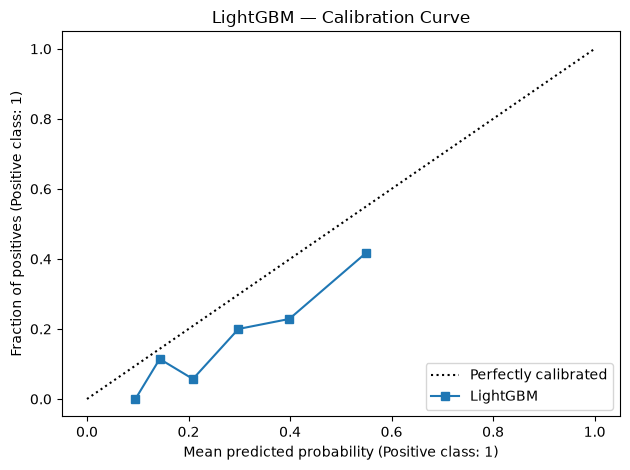

In [22]:
CalibrationDisplay.from_predictions(
    y_holdout,
    holdout_probability,
    n_bins=6,
    strategy="quantile",
    name="LightGBM",
)

plt.title("LightGBM — Calibration Curve")
plt.tight_layout()
plt.show()

## 17. Feature Importance

In [23]:
preprocessor = final_model.named_steps[
    "preprocessor"
]

classifier = final_model.named_steps[
    "classifier"
]

feature_names = [
    name.split("__", 1)[-1]
    for name in preprocessor.get_feature_names_out()
]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": classifier.feature_importances_,
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False,
    )
)

feature_importance.head(20)

,feature,importance
49,OverTime_No,2501.248761
19,YearsAtCompany,1740.183195
0,Age,1276.289711
15,StockOptionLevel,1168.154076
9,MonthlyIncome,1022.772013
4,EnvironmentSatisfaction,984.190337
8,JobSatisfaction,888.932022
2,DistanceFromHome,782.725577
16,TotalWorkingYears,764.181108
50,OverTime_Yes,688.954149


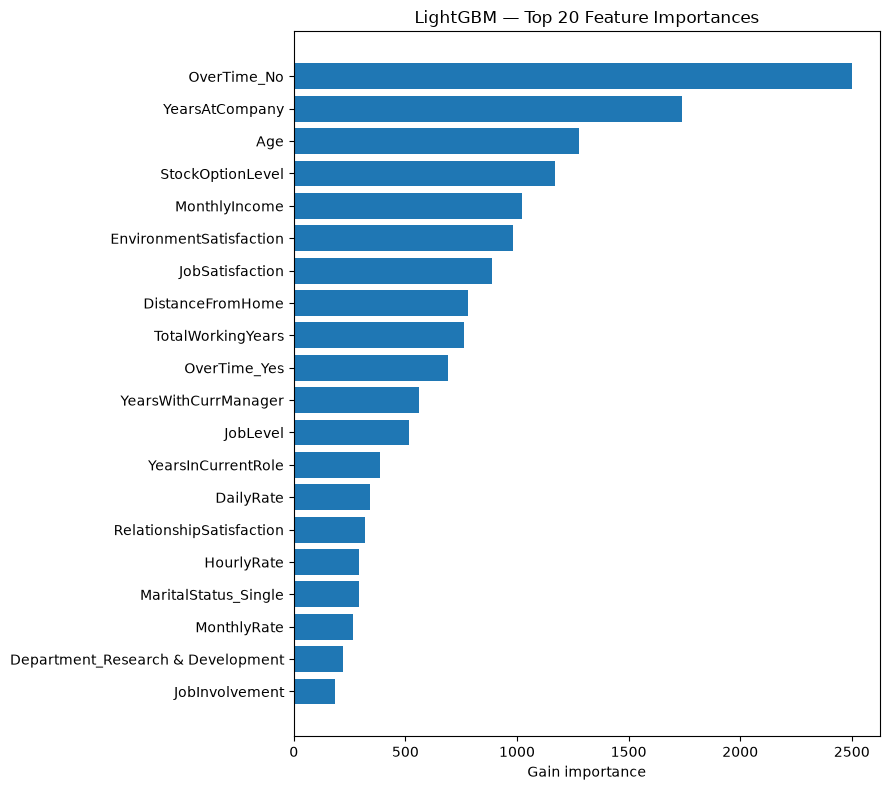

In [24]:
top_features = (
    feature_importance
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(9, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.xlabel("Gain importance")
plt.title("LightGBM — Top 20 Feature Importances")
plt.tight_layout()
plt.show()

## 18. Compare against earlier models

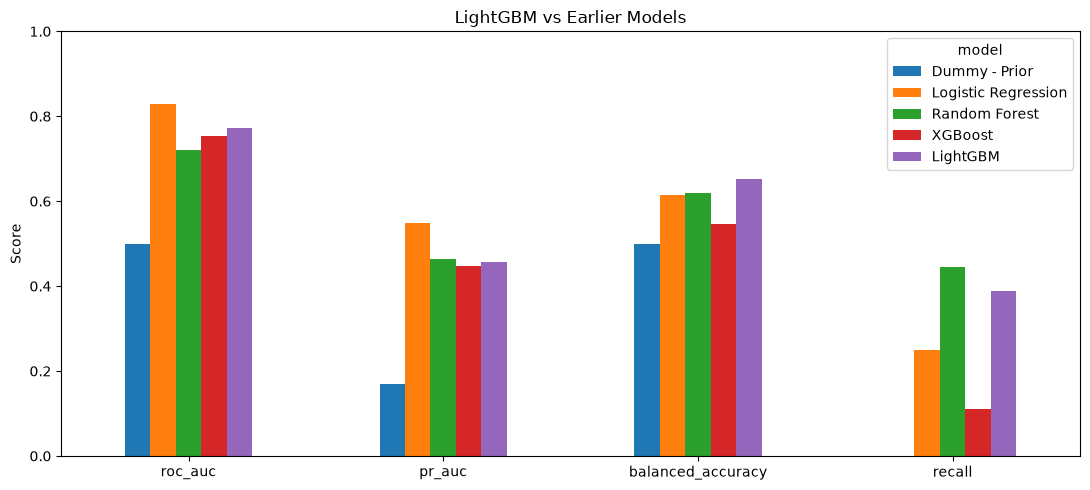

,model,roc_auc,pr_auc,balanced_accuracy,recall
0,Dummy - Prior,0.5000,0.1698,0.5000,0.0000
1,Logistic Regression,0.8278,0.5489,0.6136,0.2500
2,Random Forest,0.7194,0.4647,0.6199,0.4444
3,XGBoost,0.7539,0.4471,0.5470,0.1111
4,LightGBM,0.7730,0.4558,0.6518,0.3889


In [25]:
comparison_rows = []

baseline_path = (
    RESULTS_DIR / "baseline_results.csv"
)

logistic_path = (
    RESULTS_DIR / "logistic_regression_results.csv"
)

forest_path = (
    RESULTS_DIR / "random_forest_results.csv"
)

xgboost_path = (
    RESULTS_DIR / "xgboost_results.csv"
)

if baseline_path.exists():
    baseline = pd.read_csv(
        baseline_path
    )

    prior = baseline.loc[
        baseline["model"] == "Dummy - Prior"
    ].iloc[0]

    comparison_rows.append({
        "model": "Dummy - Prior",
        "roc_auc": prior["roc_auc"],
        "pr_auc": prior["pr_auc"],
        "balanced_accuracy": prior[
            "balanced_accuracy"
        ],
        "recall": prior["recall"],
    })

if logistic_path.exists():
    logistic = pd.read_csv(
        logistic_path
    ).iloc[0]

    comparison_rows.append({
        "model": "Logistic Regression",
        "roc_auc": logistic["roc_auc"],
        "pr_auc": logistic["pr_auc"],
        "balanced_accuracy": logistic[
            "balanced_accuracy"
        ],
        "recall": logistic["recall"],
    })

if forest_path.exists():
    forest = pd.read_csv(
        forest_path
    ).iloc[0]

    comparison_rows.append({
        "model": "Random Forest",
        "roc_auc": forest["roc_auc"],
        "pr_auc": forest["pr_auc"],
        "balanced_accuracy": forest[
            "balanced_accuracy"
        ],
        "recall": forest["recall"],
    })

if xgboost_path.exists():
    xgboost = pd.read_csv(
        xgboost_path
    ).iloc[0]

    comparison_rows.append({
        "model": "XGBoost",
        "roc_auc": xgboost["roc_auc"],
        "pr_auc": xgboost["pr_auc"],
        "balanced_accuracy": xgboost[
            "balanced_accuracy"
        ],
        "recall": xgboost["recall"],
    })

comparison_rows.append({
    "model": "LightGBM",
    "roc_auc": metrics["roc_auc"].iloc[0],
    "pr_auc": metrics["pr_auc"].iloc[0],
    "balanced_accuracy": metrics[
        "balanced_accuracy"
    ].iloc[0],
    "recall": metrics["recall"].iloc[0],
})

comparison = pd.DataFrame(
    comparison_rows
)

comparison.set_index("model").T.plot(
    kind="bar",
    figsize=(11, 5),
)

plt.title("LightGBM vs Earlier Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

comparison.round(4)

## 19. Save

In [26]:
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

feature_comparison.to_csv(
    RESULTS_DIR
    / "lightgbm_feature_set_comparison.csv",
    index=False,
)

tuning_view.to_csv(
    RESULTS_DIR
    / "lightgbm_tuning_results.csv",
    index=False,
)

model_results = metrics.copy()

model_results.insert(
    0,
    "model",
    "LightGBM",
)

model_results["feature_set"] = (
    selected_name
)

model_results["cv_pr_auc"] = (
    search.best_score_
)

model_results[
    "early_stopped_n_estimators"
] = optimal_n_estimators

for parameter, value in (
    search.best_params_.items()
):
    clean_parameter = parameter.replace(
        "classifier__",
        "best_",
    )

    model_results[
        clean_parameter
    ] = str(value)

model_results.to_csv(
    RESULTS_DIR / "lightgbm_results.csv",
    index=False,
)

pd.DataFrame({
    ID_COLUMN: development[
        ID_COLUMN
    ].values,
    "Actual": y_dev.values,
    "OOF_AttritionProbability": (
        oof_probability
    ),
}).to_csv(
    RESULTS_DIR
    / "lightgbm_oof_predictions.csv",
    index=False,
)

pd.DataFrame({
    ID_COLUMN: holdout[
        ID_COLUMN
    ].values,
    "Actual": y_holdout.values,
    "Predicted": holdout_prediction,
    "AttritionProbability": (
        holdout_probability
    ),
}).to_csv(
    RESULTS_DIR
    / "lightgbm_holdout_predictions.csv",
    index=False,
)

feature_importance.to_csv(
    RESULTS_DIR
    / "lightgbm_feature_importance.csv",
    index=False,
)

joblib.dump(
    final_model,
    MODELS_DIR
    / "lightgbm_pipeline.joblib",
)

print(
    "Results saved to:",
    RESULTS_DIR,
)

print(
    "Model saved to:",
    MODELS_DIR,
)

Results saved to: C:\Users\jeffh\PycharmProjects\employee-attrition\results
Model saved to: C:\Users\jeffh\PycharmProjects\employee-attrition\models
